In [1]:
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")
pd.set_option('future.no_silent_downcasting', True)

In [3]:
def map_0_1(x):
    return [int(i == 1) for i in x]


file_mapping = {
    'ravi_qcnn_1348': '../../qcnn/experiments/exp11_immuno_ravi_bms_riaz/1348_binding_ravi.pkl',
    'ravi_qcnn_2456': '../../qcnn/experiments/exp11_immuno_ravi_bms_riaz/2456_immuno_binders_ravi.pkl',
    
    'ravi_ccnn_ltd_1348': '../../ccnn/output/limited_params/survival_results/1348_binding_ravi/results.csv',
    'ravi_ccnn_ltd_2456': '../../ccnn/output/limited_params/survival_results/2456_immuno_binders_ravi/results.csv',
    
    'ravi_ccnn_large_1348': '../../ccnn/output/large_params/survival_results/1348_binding_ravi/results.csv',
    'ravi_ccnn_large_2456': '../../ccnn/output/large_params/survival_results/2456_immuno_binders_ravi/results.csv',
    
    'rf_1348': '../../random_forest/experiments/binding_ravi_1348/pred_labels.pkl',
    'rf_2456': '../../random_forest/experiments/immuno_ravi_2456/pred_labels.pkl',
    
    'ravi_data': '../../qcnn/input_data/Ravi_Riaz_data/Ravi_2023_NatGen_patient.txt',
    'ravi_encoded': '../../qcnn/input_data/Ravi_Riaz_data/encoded_data/ravi_encoded_a0201.csv',    
    'ravi_ba': '../../qcnn/input_data/Ravi_Riaz_data/Ravi_2023_NatGen_samples_a0201_barank.csv',
}

# get predicted qcnn labels 
with open(file_mapping['ravi_qcnn_2456'], 'rb') as f:
    qcnn_2456 = np.array(map_0_1(pickle.load(f)['test_pred']))
with open(file_mapping['ravi_qcnn_1348'], 'rb') as f:
    qcnn_1348 = np.array(map_0_1(pickle.load(f)['test_pred']))
qcnn_labels = qcnn_2456 & qcnn_1348
    
# load peptide samples & NetMHC labels
encoded_data = pd.read_csv(file_mapping[f'ravi_encoded'])
patients = encoded_data['Sample'].to_numpy()

netmhc_labels = encoded_data['BA_rank'].to_numpy()[:len(qcnn_labels)]
netmhc_labels = [1 if i < 2 else 0 for i in netmhc_labels ]

print(f'Ravi --- Labels: {len(qcnn_labels)} --- Patients: {len(set(patients))}')

# create df with patient id and qcnn_pred --> group by patient id and get the counts
df = pd.DataFrame({"patient": patients, "qcnn": qcnn_labels.astype(int), "netMHC": netmhc_labels})

# ensure all patients are in the data frame (even if count is 0)
all_patients = pd.DataFrame({"patient": patients}).drop_duplicates()
df = (all_patients.merge(df, on="patient", how="left").fillna(0))

# get ccnn ltd preds
data = pd.read_csv(file_mapping['ravi_ccnn_ltd_1348'])
ccnn_limited_1348 = np.array(ast.literal_eval(data['pred_labels'][0]))
data = pd.read_csv(file_mapping['ravi_ccnn_ltd_2456'])
ccnn_limited_2456 = np.array(ast.literal_eval(data['pred_labels'][0]))
ccnn_ltd_labels = ccnn_limited_2456 & ccnn_limited_1348
df['ccnn_ltd'] = ccnn_ltd_labels

# get ccnn large preds
data = pd.read_csv(file_mapping['ravi_ccnn_large_1348'])
ccnn_large_1348 = np.array(ast.literal_eval(data['pred_labels'][0]))
data = pd.read_csv(file_mapping['ravi_ccnn_large_2456'])
ccnn_large_2456 = np.array(ast.literal_eval(data['pred_labels'][0]))
ccnn_large_labels = ccnn_large_2456 & ccnn_large_1348
df['ccnn_large'] = ccnn_large_labels

# get rf preds
with open(file_mapping['rf_1348'], 'rb') as f:
    rf_1348 = pickle.load(f)['avg_pred_labels']
with open(file_mapping['rf_2456'], 'rb') as f:
    rf_2456 = pickle.load(f)['avg_pred_labels']
rf_labels = rf_2456 & rf_1348
df['rf'] = rf_labels
    
df.head(10)

Ravi --- Labels: 209889 --- Patients: 111


,patient,qcnn,netMHC,ccnn_ltd,ccnn_large,rf
0,SU2CLC-DFC-DF0899-T1,0,0,0,0,0
1,SU2CLC-DFC-DF0899-T1,0,0,0,0,0
2,SU2CLC-DFC-DF0899-T1,1,0,0,0,0
3,SU2CLC-DFC-DF0899-T1,0,0,0,0,0
4,SU2CLC-DFC-DF0899-T1,0,0,0,0,0
5,SU2CLC-DFC-DF0899-T1,0,0,0,0,0
6,SU2CLC-DFC-DF0899-T1,0,0,1,0,1
7,SU2CLC-DFC-DF0899-T1,0,0,0,0,0
8,SU2CLC-DFC-DF0899-T1,1,0,1,1,1
9,SU2CLC-DFC-DF0899-T1,0,0,0,0,0


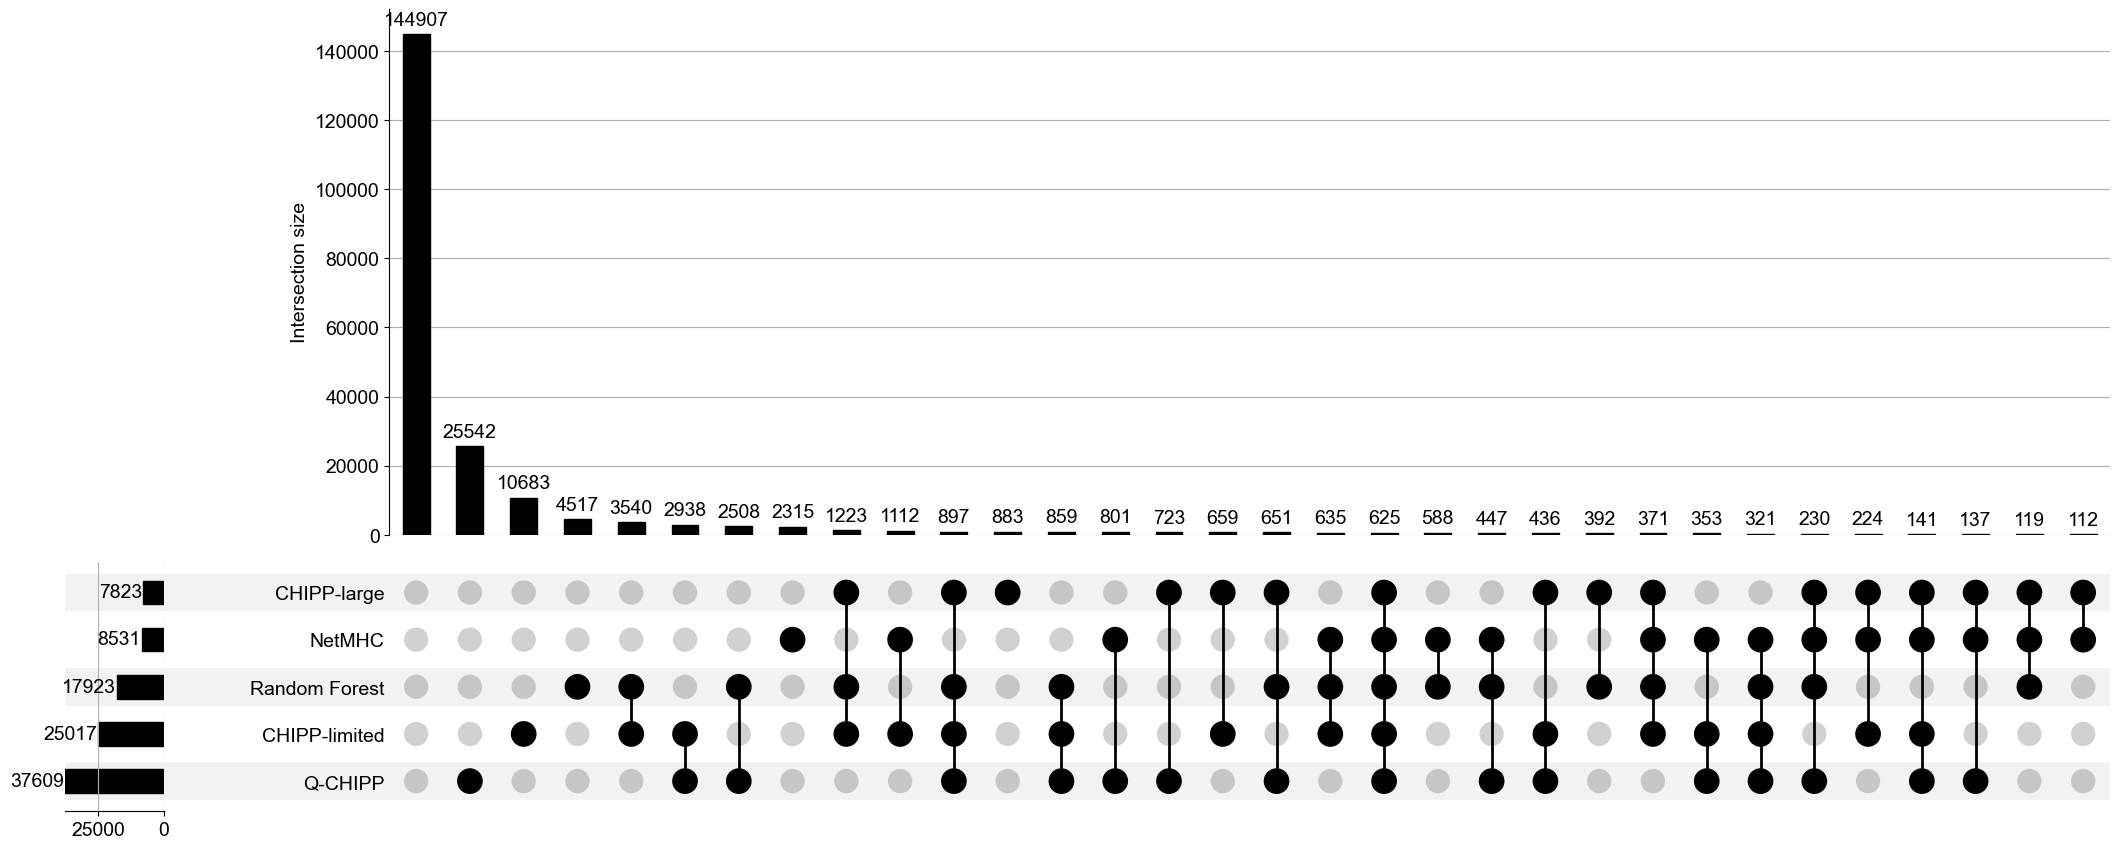

In [5]:
# convert to labeled Series
quantum_positive  = pd.Series(df['qcnn'] == 1, name = 'QCNN')
classical_small_positive = pd.Series(df['ccnn_ltd'] == 1, name = 'CNN Large')
classical_large_positive = pd.Series(df['ccnn_large'] == 1, name = 'CNN Large')
netmhc_positive = pd.Series(df['netMHC'] == 1, name = 'NetMHC')
rf_positive = pd.Series(df['rf'] == 1, name='Random Forest')

# determine memberships based on correctness
memberships = []
for qc, scc, lcc, ba, rfc in zip(quantum_positive, classical_small_positive, classical_large_positive, netmhc_positive, rf_positive):
    mem = []
    if qc:
        mem.append('Q-CHIPP')
    if scc:
        mem.append('CHIPP-limited')
    if lcc:
        mem.append('CHIPP-large')
    if ba:
        mem.append('NetMHC')
    if rfc:
        mem.append('Random Forest')
    memberships.append(mem)

data = from_memberships(memberships)

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14
})

fig = plt.figure(figsize=(8, 5))
up = UpSet(
    data,
    subset_size='count',
    show_counts=True,
    show_percentages=False,
    sort_by='cardinality',
    intersection_plot_elements=10,
    element_size=50
)
up.plot(fig=fig)

plt.savefig('survival_plots_e.svg', dpi=300, bbox_inches='tight')
plt.show()